In [29]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
%config InlineBackend.figure_format = 'retina'

# Important: add project root in the next cell

In [31]:
import sys

sys.path.insert(0, "/home/jlin/projects/vlm_pred/")
# sys.path.insert(0, "<ADD YOUR PROJECT ROOT HERE>")

In [32]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from vlm_pred.data import load_data_df, train_test_split
from vlm_pred.metric import evaluate
from vlm_pred.config import VAL_CUTOFF, OOS_CUTOFF

pd.set_option('display.max_columns', None)

# Load Data

In [5]:
from vlm_pred.data import load_data_df, train_test_split

In [6]:
data_df = load_data_df()
print(f"found data_df {data_df.shape}")

train_df, val_df, oos_df = train_test_split(data_df)
print(f"found train_df {train_df.shape}")
print(f"found val_df {val_df.shape}")
print(f"found oos_df {oos_df.shape}")

found data_df (2250490, 11)
found train_df (1045454, 11)
found val_df (586280, 11)
found oos_df (618756, 11)


# Q1: Descriptive Study

## Distribution of y

In [7]:
train_df[['y']].describe()

,y
count,1.045006e+06
mean,3.651175e-02
std,6.860714e-01
min,-1.000000e+00
25%,-3.250138e-01
50%,-1.033853e-01
75%,2.046806e-01
max,1.000000e+01


In [9]:
train_df[['y']].agg(['skew'])

,y
skew,5.423368


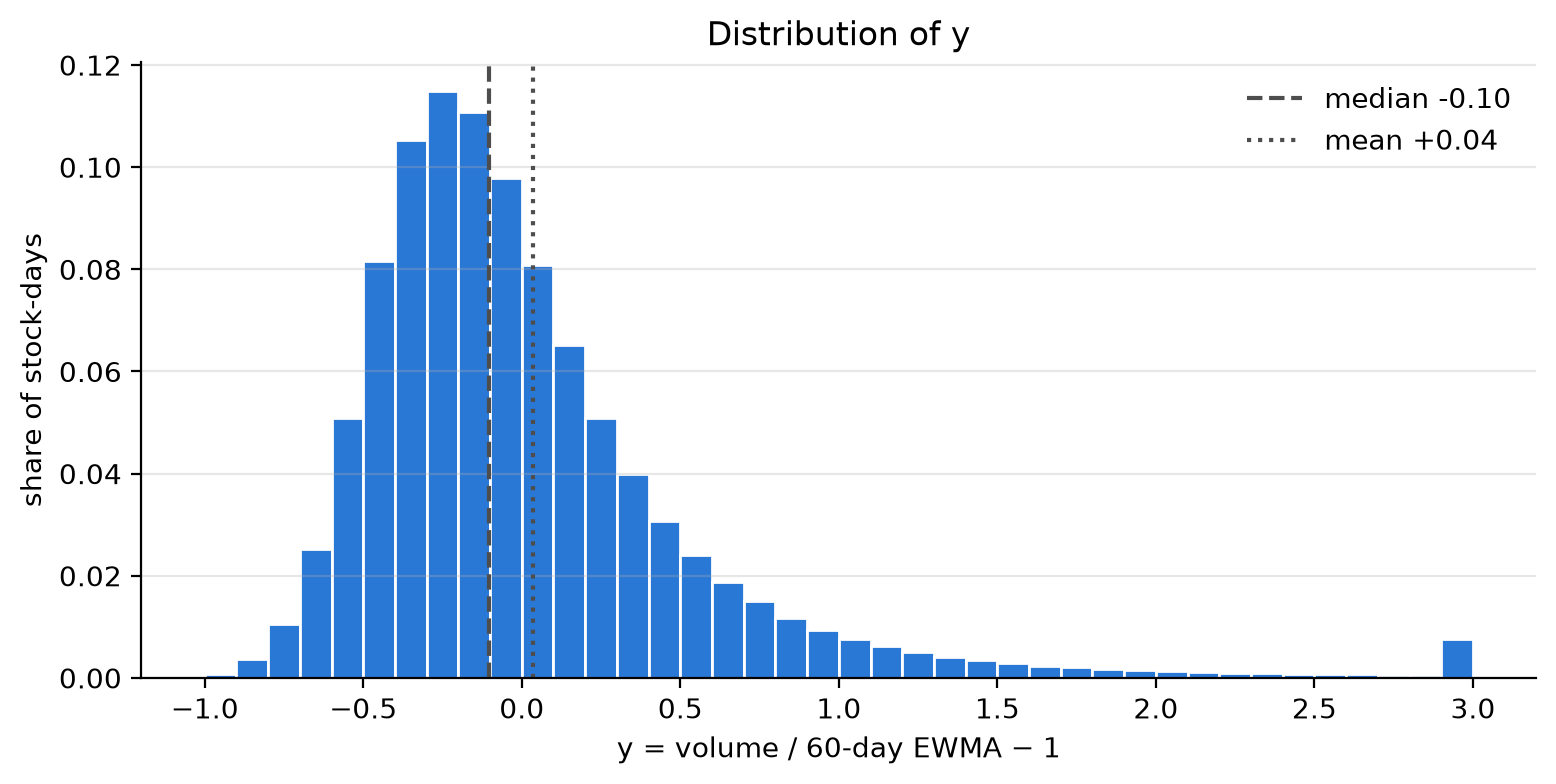

In [10]:
import numpy as np
import matplotlib.pyplot as plt

y = train_df['y'].dropna()
w = np.ones(len(y)) / len(y)  # bar heights as share of stock-days

fig, ax = plt.subplots(figsize=(9, 4))
bins = np.linspace(-1, 3, 41)  # 40 bins of width 0.1, last edge exactly 3.0
ax.hist(y.clip(upper=3), bins=bins, weights=w, color='#2a78d6', edgecolor='white')
ax.axvline(y.median(), color='0.3', ls='--', label=f'median {y.median():+.2f}')
ax.axvline(y.mean(), color='0.3', ls=':', label=f'mean {y.mean():+.2f}')
ax.legend(frameon=False)

ax.set(title='Distribution of y', xlabel='y = volume / 60-day EWMA − 1', ylabel='share of stock-days')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.show()

In [14]:
def share_of_variance(y, w, cutoff):
    mask = np.isfinite(y) & np.isfinite(w)
    y = y[mask]
    w = w[mask]
    d = w * (y - (w * y).sum() / w.sum()) ** 2
    share = d[y > cutoff].sum() / d.sum()
    return share

In [19]:
var_share = share_of_variance(train_df['y'], train_df['sp_weight'], cutoff=1).item()
print(f"Share of variance from y > 1 events: {100*var_share:.0f}%")

Share of variance from y>1 events: 68%


## Market-wide distribution

In [20]:
y_mean = train_df.groupby('date').apply(lambda x: (x['sp_weight']*x['y']).sum()/x['sp_weight'].sum())

In [21]:
y_mean.describe()

count    2514.000000
mean        0.025029
std         0.214844
min        -0.776358
25%        -0.103878
50%         0.007989
75%         0.124087
max         1.528217
dtype: float64

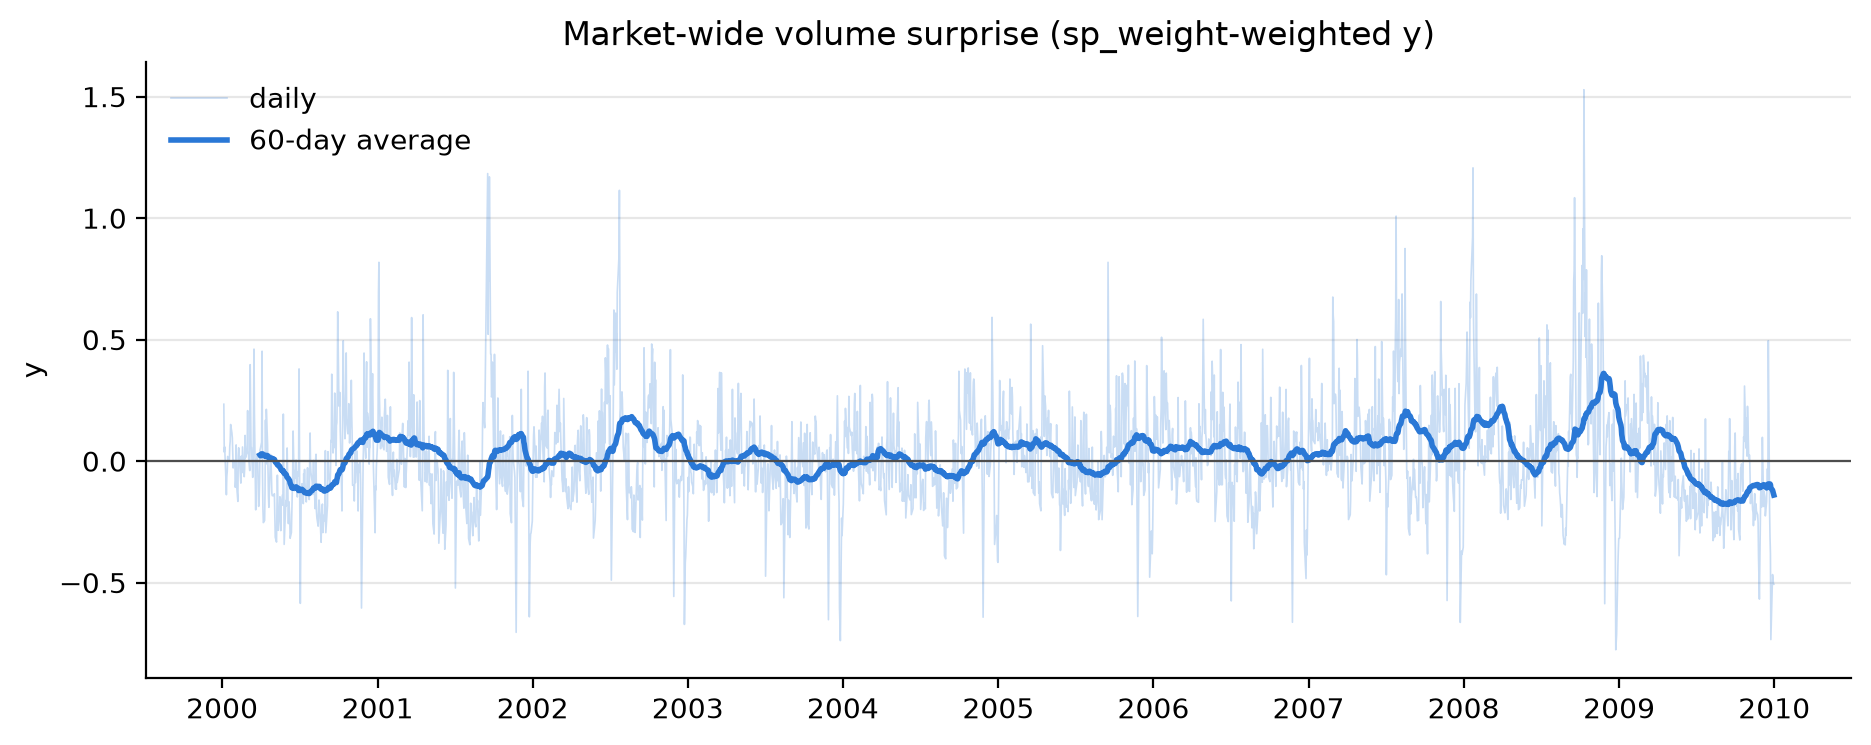

In [22]:
import matplotlib.pyplot as plt

# sp_weight-weighted mean of y per date (vectorized; skips rows where y is NaN)
w = train_df['sp_weight'].where(train_df['y'].notna())
y_mean = (train_df['y'] * w).groupby('date').sum() / w.groupby('date').sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(y_mean.index, y_mean, color='#2a78d6', alpha=0.25, lw=0.6, label='daily')
ax.plot(y_mean.index, y_mean.rolling(60).mean(), color='#2a78d6', lw=2, label='60-day average')
ax.axhline(0, color='0.3', lw=0.8)

ax.set(title='Market-wide volume surprise (sp_weight-weighted y)', ylabel='y')
ax.legend(frameon=False, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.show()

## Calendar Effect

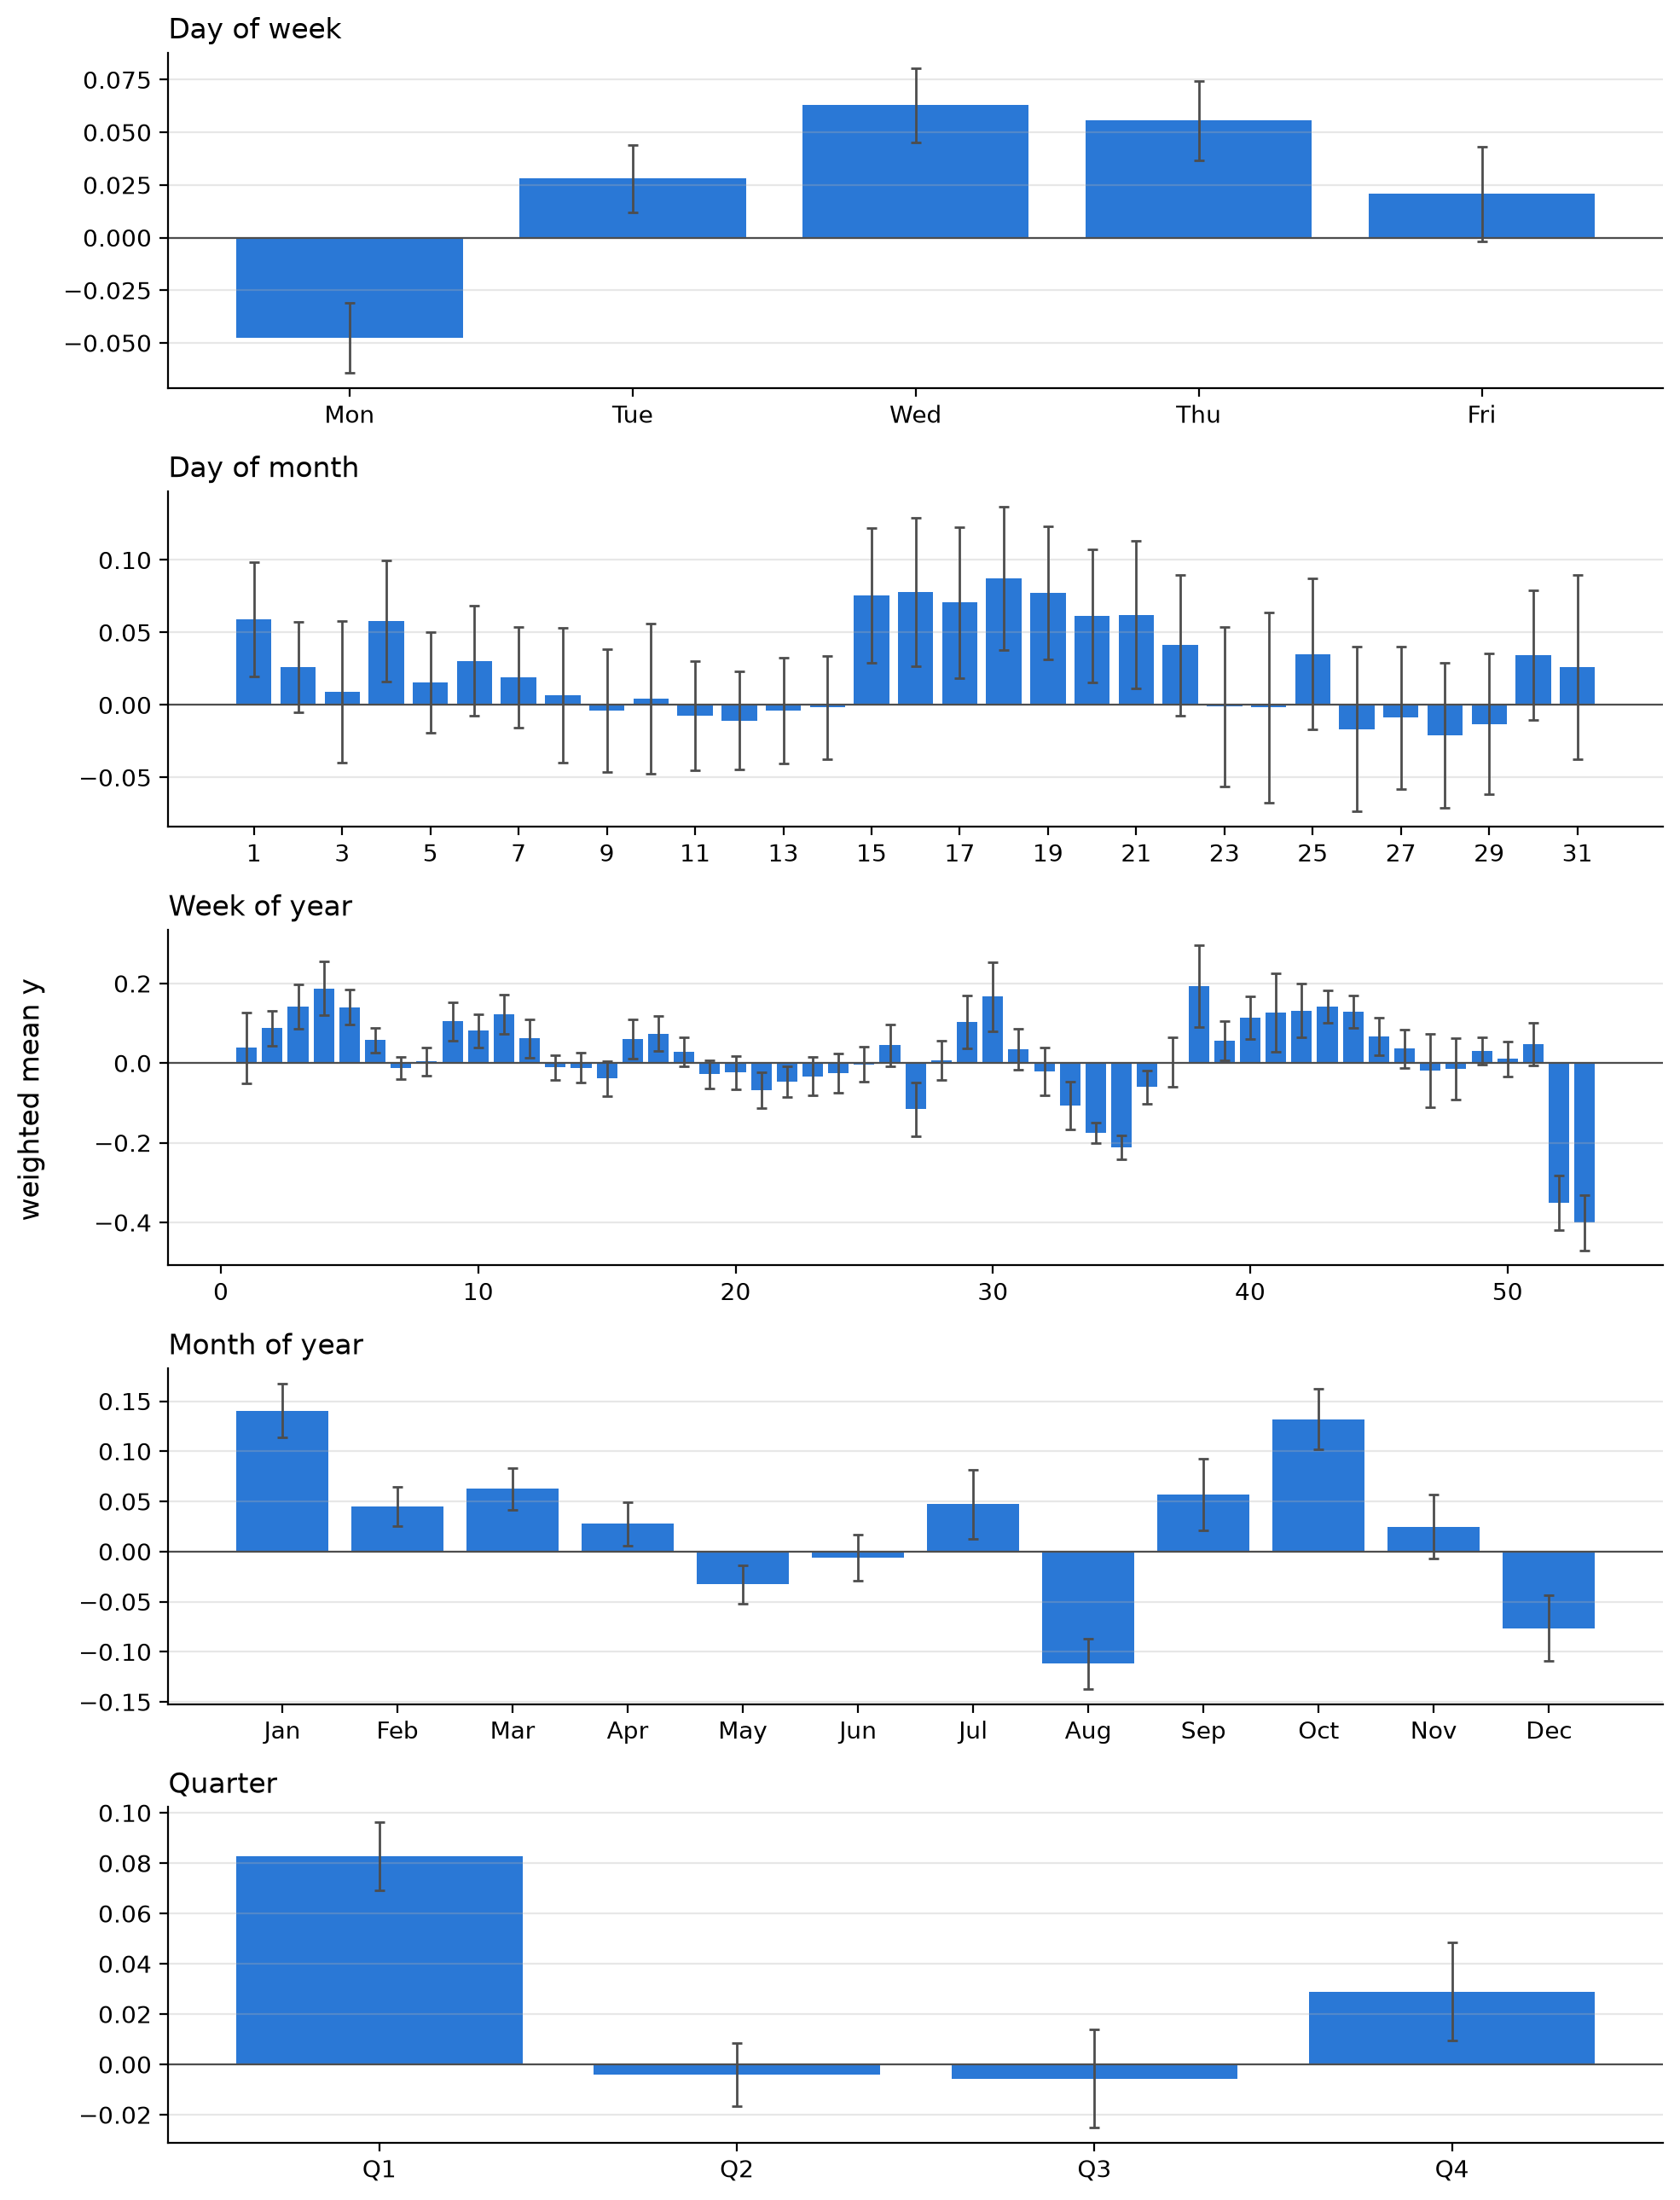

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# One sp_weight-weighted mean of y per date
w = train_df['sp_weight'].where(train_df['y'].notna())
daily = (train_df['y'] * w).groupby('date').sum() / w.groupby('date').sum()
d = pd.DatetimeIndex(daily.index)

groups = {
    'Day of week': d.dayofweek,                       # 0 = Monday
    'Day of month': d.day,
    'Week of year': d.isocalendar().week.to_numpy(),
    'Month of year': d.month,
    'Quarter': d.quarter,
}

fig, axes = plt.subplots(len(groups), 1, figsize=(10, 13))
for ax, (name, key) in zip(axes, groups.items()):
    g = daily.groupby(key)
    mean, se = g.mean(), g.std() / np.sqrt(g.count())
    ax.bar(mean.index, mean.values, yerr=1.96 * se.values, color='#2a78d6',
           error_kw=dict(ecolor='0.3', elinewidth=1, capsize=2))
    ax.axhline(0, color='0.3', lw=0.8)
    ax.set_title(name, loc='left')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

axes[0].set_xticks(range(5), ['Mon', 'Tue', 'Wed', 'Thu', 'Fri'])
axes[1].set_xticks(range(1, 32, 2))
axes[3].set_xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                  'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[4].set_xticks(range(1, 5), ['Q1', 'Q2', 'Q3', 'Q4'])
fig.supylabel('weighted mean y')
fig.tight_layout()
plt.show()

## Corporate Action

ret_raw really is calculated using price_adj, not price_close. So it already takes into account corporate action adjustments.

In [25]:
# Check that the provided ret_raw matches returns recomputed from adjusted prices
RET_TOL = 1e-4

ret_calc = train_df.groupby('uspn')['price_adj'].pct_change()
mismatch = ret_calc.notna() & ~np.isclose(train_df['ret_raw'], ret_calc, rtol=0, atol=RET_TOL)

assert not mismatch.any(), 'mismatch between calculate return and ret_raw found'

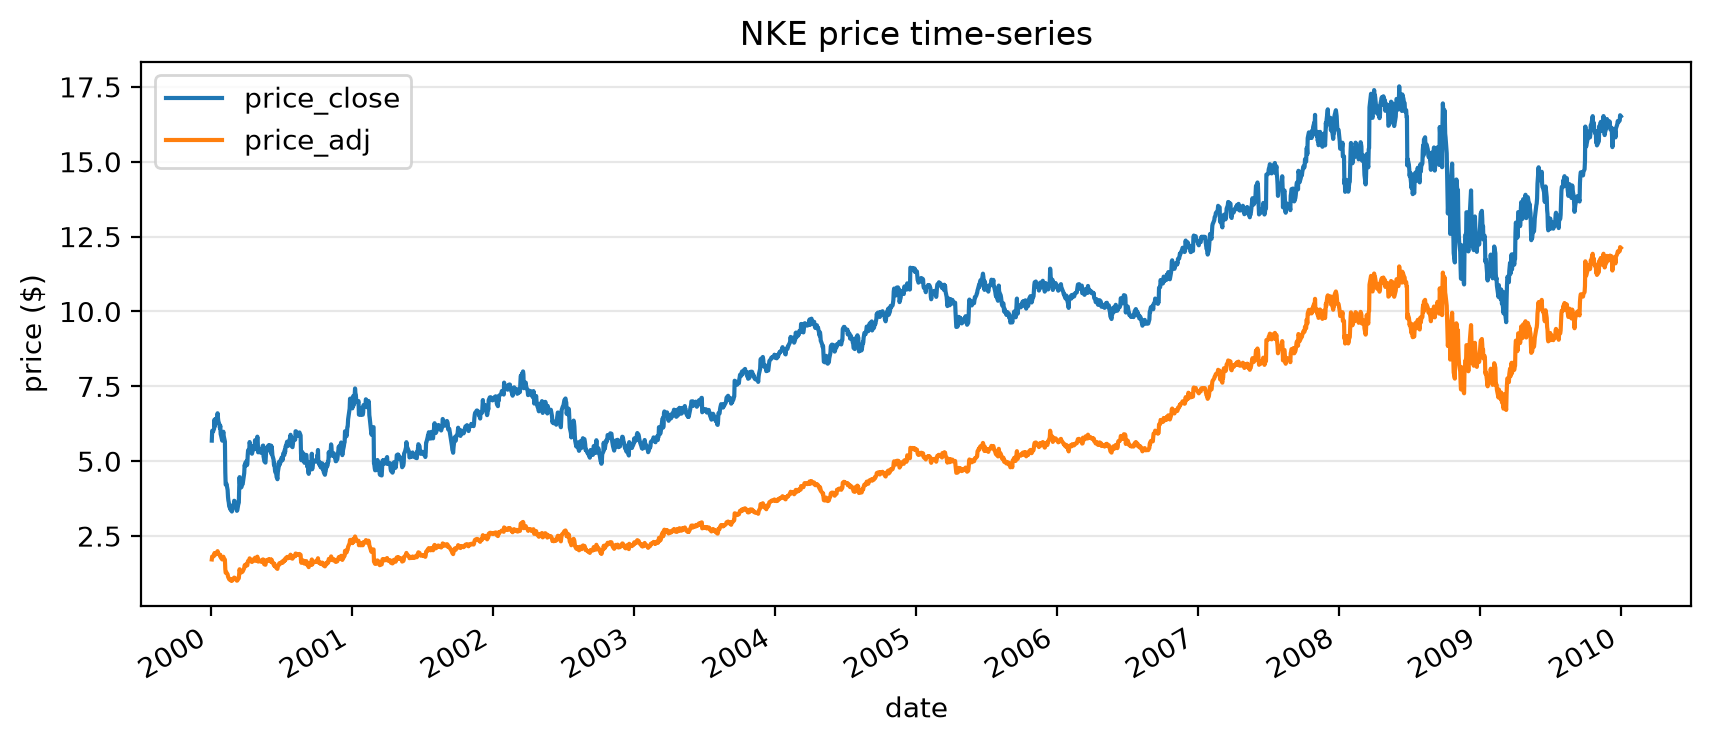

In [26]:
# sanity check on NKE

fig, ax = plt.subplots(figsize=(10, 4))
ax.set(title=f'NKE price time-series', ylabel='price ($)')
train_df.xs('NKE', level='uspn')['price_close'].plot(ax=ax)
train_df.xs('NKE', level='uspn')['price_adj'].plot(ax=ax)
ax.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

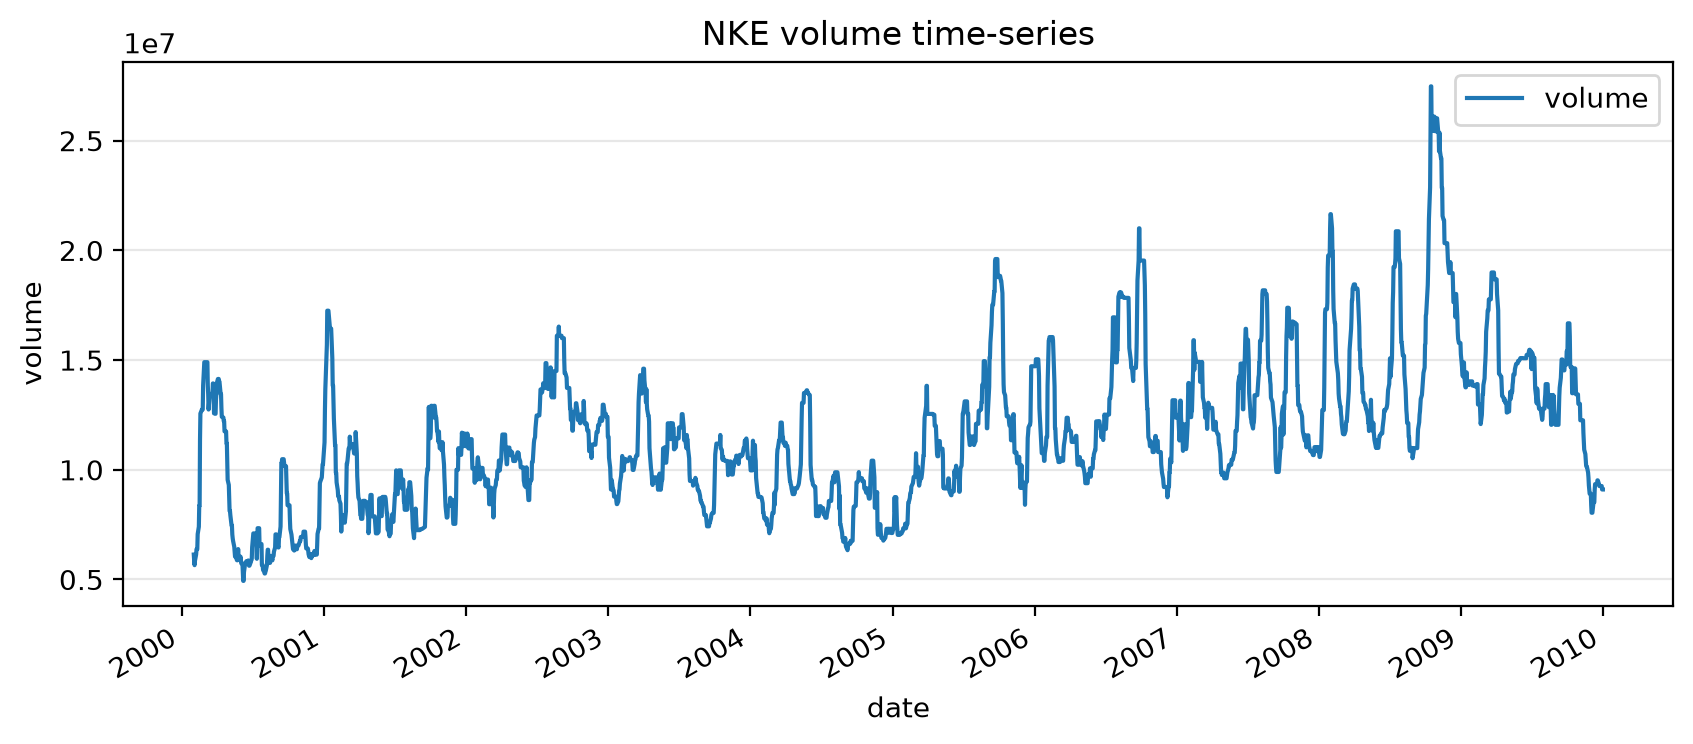

In [27]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.set(title=f'NKE volume time-series', ylabel='volume')
train_df.xs('NKE', level='uspn')['volume'].rolling(20).median().plot(ax=ax)
ax.grid(axis='y', alpha=0.3)
plt.legend()
plt.show()

## Auto-correlation

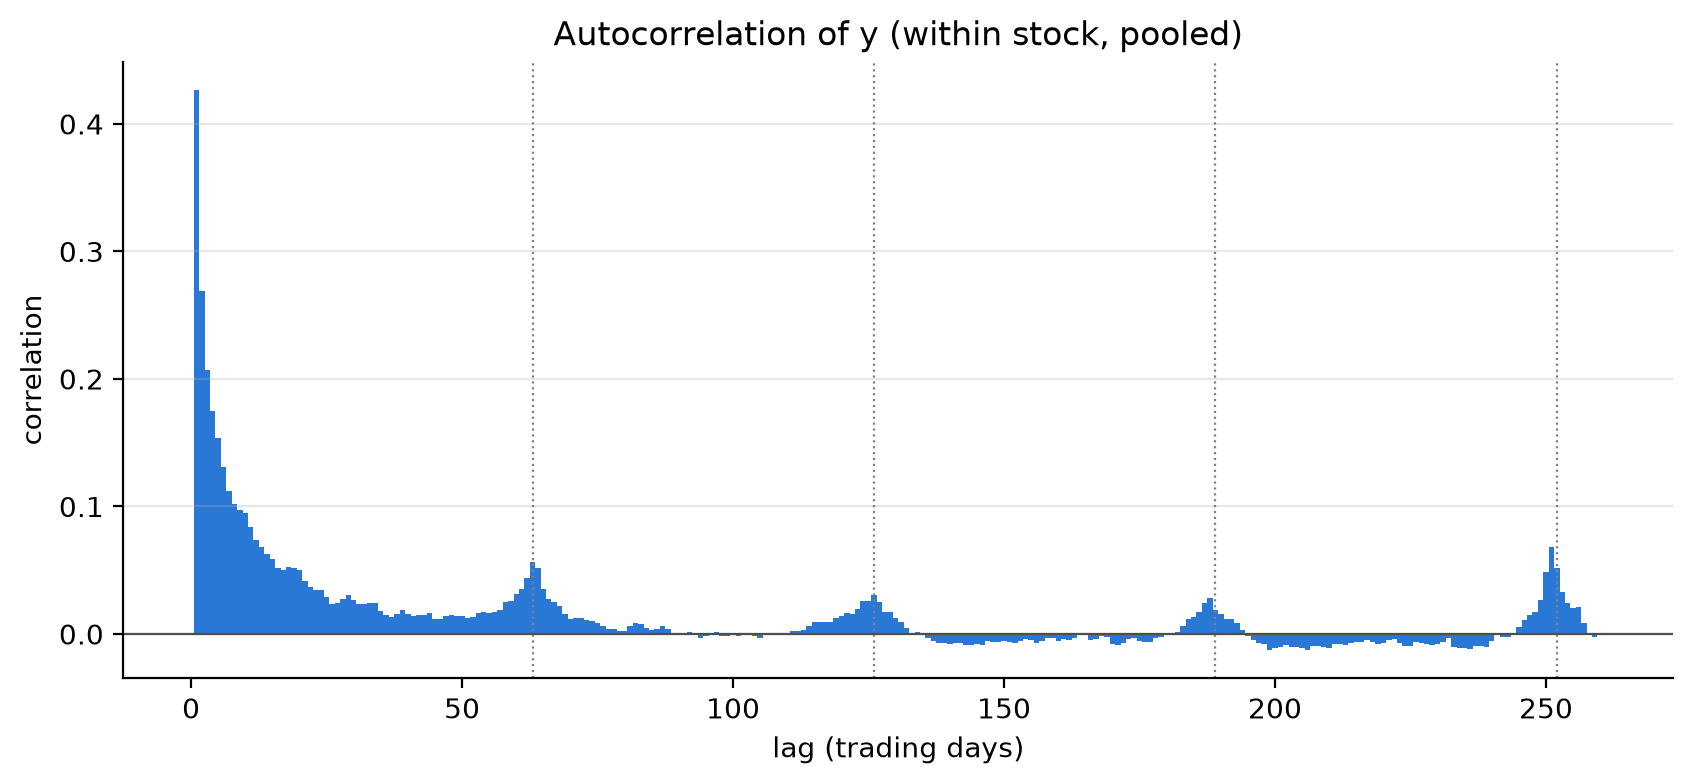

In [28]:
import numpy as np
import matplotlib.pyplot as plt

acf_df = train_df.copy()
g = acf_df.groupby(level='uspn')['y']
lags = np.arange(1, 261)
acf = [acf_df['y'].corr(g.shift(k)) for k in lags]   # pooled over stocks; ~1 min

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lags, acf, width=1, color='#2a78d6')
for k in (63, 126, 189, 252):                         # ~1, 2, 3, 4 quarters
    ax.axvline(k, color='0.5', ls=':', lw=0.8)
ax.axhline(0, color='0.3', lw=0.8)

ax.set(title='Autocorrelation of y (within stock, pooled)', xlabel='lag (trading days)', ylabel='correlation')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.show()

# Q2: model

In [36]:
from vlm_pred.data import load_data_df
from vlm_pred.main import build_features, run_score

In [34]:
df, features = build_features(load_data_df())

loaded df: (2250490, 8) from /home/jlin/projects/vlm_pred/data/sp500.h5
enriching 9 features ...


In [37]:
run_score(df, features)

  0%|          | 0/20 [00:00<?, ?it/s]

default  in-sample      R² = 0.3117   t = 807.3
default  out-of-sample  R² = 0.3554   t = 584.1


  0%|          | 0/20 [00:00<?, ?it/s]

tuned    in-sample      R² = 0.3163   t = 815.9
tuned    out-of-sample  R² = 0.3630   t = 593.8


# Hyper-parameter tuning

In [33]:
from lightgbm import LGBMRegressor
from vlm_pred.walkforward import WalkForward
from vlm_pred.tune import tune

In [34]:
wf = WalkForward(model=LGBMRegressor(random_state=42, verbose=-1, objective='gamma',
                                     deterministic=True, force_col_wise=True),
                 features=features, target=target_ratio, weight=weight, train_window=None)

In [35]:
study = tune(wf, pd.concat([train_df, val_df], axis=0), target=target, weight=weight, n_trials=100, out_dir='../trials')

[I 2026-10-06 23:28:22,710] A new study created in memory with name: no-name-ea0d672a-a723-4c33-b90f-e09c25ea3553


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-10-06 23:30:22,822] Trial 0 finished with value: 0.30277498199933506 and parameters: {'n_estimators': 236, 'learning_rate': 0.17254716573280354, 'num_leaves': 118, 'min_child_samples': 540, 'colsample_bytree': 0.5780093202212182, 'reg_lambda': 0.0060252157362038605}. Best is trial 0 with value: 0.30277498199933506.


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-10-06 23:31:35,426] Trial 1 finished with value: 0.3098862715629622 and parameters: {'n_estimators': 114, 'learning_rate': 0.13394334706750485, 'num_leaves': 81, 'min_child_samples': 990, 'colsample_bytree': 0.5102922471479012, 'reg_lambda': 70.72114131472235}. Best is trial 1 with value: 0.3098862715629622.


...

[I 2026-10-07 13:43:11,276] Trial 97 finished with value: 0.3158810481322747 and parameters: {'n_estimators': 871, 'learning_rate': 0.011375373808884336, 'num_leaves': 152, 'min_child_samples': 25, 'colsample_bytree': 0.5247468017814613, 'reg_lambda': 0.00835008767287255}. Best is trial 16 with value: 0.3162991294127223.


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-10-07 13:52:04,445] Trial 98 finished with value: 0.31571181661676007 and parameters: {'n_estimators': 953, 'learning_rate': 0.014599757444247536, 'num_leaves': 211, 'min_child_samples': 28, 'colsample_bytree': 0.5438285481764757, 'reg_lambda': 0.003124484774793444}. Best is trial 16 with value: 0.3162991294127223.


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-10-07 14:02:03,865] Trial 99 finished with value: 0.3157959521509469 and parameters: {'n_estimators': 982, 'learning_rate': 0.010287640990989283, 'num_leaves': 193, 'min_child_samples': 25, 'colsample_bytree': 0.5526677348689264, 'reg_lambda': 0.004335469167619867}. Best is trial 16 with value: 0.3162991294127223.


In [39]:
study.best_params

{'n_estimators': 963,
 'learning_rate': 0.01025674056791372,
 'num_leaves': 190,
 'min_child_samples': 35,
 'colsample_bytree': 0.5201068463749413,
 'reg_lambda': 0.01957113058068085}

In [37]:
study.best_value

0.3162991294127223

In [38]:
trials_df = study.trials_dataframe()